In [1]:
import numpy as np
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict

# Optional plotting
import matplotlib.pyplot as plt

# Optional triangulation helper
from scipy.spatial import Delaunay

# Physical constants
c0 = 299_792_458.0
mu0 = 4e-7 * np.pi
eps0 = 1.0 / (mu0 * c0**2)
eta0 = np.sqrt(mu0 / eps0)

In [2]:
def norm(v, axis=-1, keepdims=False):
    return np.linalg.norm(v, axis=axis, keepdims=keepdims)

def unit(v, axis=-1):
    n = norm(v, axis=axis, keepdims=True)
    n = np.where(n < 1e-15, 1.0, n)
    return v / n

def dot(a, b, axis=-1):
    return np.sum(a * b, axis=axis)

def cross(a, b):
    return np.cross(a, b)

def reflect(i_hat, n_hat):
    # i_hat and n_hat are unit vectors
    return i_hat - 2.0 * dot(i_hat, n_hat)[..., None] * n_hat

def refract_heckbert(i_hat, n_hat, n1, n2):
    """
    Vector refraction formula in the style used in the paper.
    Returns transmitted unit vector and a boolean for valid transmission.
    
    Convention:
    - i_hat: incident propagation direction
    - n_hat: interface unit normal oriented from medium 1 to medium 2
    - n1, n2: refractive indices
    """
    alpha = n1 / n2
    d = dot(i_hat, n_hat)
    rad = 1.0 - alpha**2 * (1.0 - d**2)
    valid = rad >= 0.0
    b = np.sqrt(np.maximum(rad, 0.0))
    t_hat = alpha * i_hat + (b - alpha * d)[..., None] * n_hat
    t_hat = unit(t_hat)
    return t_hat, valid

def spherical_directions(n_theta=41, n_phi=81, hemisphere='upper'):
    """
    Generate unit directions over the sphere or upper hemisphere.
    """
    if hemisphere == 'upper':
        theta = np.linspace(0.0, np.pi/2, n_theta)
    else:
        theta = np.linspace(0.0, np.pi, n_theta)
    phi = np.linspace(0.0, 2*np.pi, n_phi, endpoint=False)

    TH, PH = np.meshgrid(theta, phi, indexing='ij')
    x = np.sin(TH) * np.cos(PH)
    y = np.sin(TH) * np.sin(PH)
    z = np.cos(TH)
    dirs = np.stack([x, y, z], axis=-1).reshape(-1, 3)
    return unit(dirs)

In [3]:
@dataclass
class Ray:
    r0: np.ndarray          # current point, shape (3,)
    k_hat: np.ndarray       # current propagation direction, shape (3,)
    phase: float = 0.0      # accumulated phase in radians
    amp: float = 1.0        # scalar amplitude
    alive: bool = True
    medium_index: int = 0
    history: List[np.ndarray] = field(default_factory=list)
    normals: List[np.ndarray] = field(default_factory=list)

@dataclass
class Surface:
    name: str
    eps_r_above: float
    eps_r_below: float
    
    def z(self, x, y):
        raise NotImplementedError
    
    def dzdx(self, x, y):
        raise NotImplementedError
    
    def dzdy(self, x, y):
        raise NotImplementedError
    
    def normal(self, x, y):
        """
        For z = f(x,y), implicit form F(x,y,z)=z-f(x,y)=0
        grad(F)=(-fx,-fy,1)
        """
        fx = self.dzdx(x, y)
        fy = self.dzdy(x, y)
        n = np.stack([-fx, -fy, np.ones_like(fx)], axis=-1)
        return unit(n)

@dataclass
class ConicSurface(Surface):
    c: float         # curvature parameter
    K: float         # conic constant
    z0: float        # vertex offset
    
    def z(self, x, y):
        r2 = x**2 + y**2
        root = np.maximum(1.0 - (1.0 + self.K) * (self.c**2) * r2, 1e-14)
        return self.z0 + (self.c * r2) #/ (1.0 + np.sqrt(root))
    
    def dzdx(self, x, y):
        h = 1e-7
        return (self.z(x + h, y) - self.z(x - h, y)) / (2*h)
    
    def dzdy(self, x, y):
        h = 1e-7
        return (self.z(x, y + h) - self.z(x, y - h)) / (2*h)

@dataclass
class PlaneSurface(Surface):
    z_plane: float
    
    def z(self, x, y):
        return np.full_like(x, self.z_plane, dtype=float)
    
    def dzdx(self, x, y):
        return np.zeros_like(x, dtype=float)
    
    def dzdy(self, x, y):
        return np.zeros_like(x, dtype=float)

In [4]:
@dataclass
class ArrayElement:
    position: np.ndarray   # shape (3,)
    phase_exc: float = 0.0
    amp_exc: float = 1.0

@dataclass
class ArrayAntenna:
    elements: List[ArrayElement]
    
    def positions(self):
        return np.array([e.position for e in self.elements])

def build_rect_array(nx=4, ny=4, dx=0.5, dy=0.5, wavelength=1.0, z0=0.0):
    """
    Rectangular array in the xy-plane.
    dx, dy in wavelengths unless wavelength is rescaled externally.
    """
    xs = (np.arange(nx) - (nx - 1) / 2) * dx * wavelength
    ys = (np.arange(ny) - (ny - 1) / 2) * dy * wavelength
    
    elems = []
    for x in xs:
        for y in ys:
            elems.append(ArrayElement(position=np.array([x, y, z0], dtype=float)))
    return ArrayAntenna(elems)

def gaussian_element_pattern(k_hat, q=2.0):
    """
    Simple scalar element pattern over upper hemisphere.
    Uses cos(theta)^q where theta is from +z axis.
    """
    cos_theta = np.clip(k_hat[..., 2], 0.0, 1.0)
    return cos_theta**q

In [5]:
def intersect_ray_surface(ray_origin, ray_dir, surface, t_min=1e-6, t_max=10.0, n_steps=200):
    """
    Finds first positive intersection of a ray with z = surface.z(x,y).
    Ray: r(t) = ray_origin + t * ray_dir

    Solve:
        z0 + t*dz = surface.z(x0 + t*dx, y0 + t*dy)

    Returns:
        t_hit, point_hit, normal_hit
    or
        None, None, None
    """
    x0, y0, z0 = ray_origin
    dx, dy, dz = ray_dir

    ts = np.linspace(t_min, t_max, n_steps)
    xs = x0 + ts * dx
    ys = y0 + ts * dy
    zs = z0 + ts * dz
    fs = zs - surface.z(xs, ys)

    sign_change = np.where(np.sign(fs[:-1]) * np.sign(fs[1:]) <= 0)[0]
    if len(sign_change) == 0:
        return None, None, None

    i = sign_change[0]
    a, b = ts[i], ts[i + 1]

    for _ in range(50):
        m = 0.5 * (a + b)
        xm = x0 + m * dx
        ym = y0 + m * dy
        zm = z0 + m * dz
        fm = zm - surface.z(np.array([xm]), np.array([ym]))[0]

        xa = x0 + a * dx
        ya = y0 + a * dy
        za = z0 + a * dz
        fa = za - surface.z(np.array([xa]), np.array([ya]))[0]

        if fa * fm <= 0:
            b = m
        else:
            a = m

    t_hit = 0.5 * (a + b)
    p = ray_origin + t_hit * ray_dir
    n = surface.normal(np.array([p[0]]), np.array([p[1]]))[0]
    return t_hit, p, n

In [6]:
@dataclass
class LensSystem:
    surfaces: List[Surface]
    medium_eps: List[float]
    # Example:
    # medium_eps = [1.0, 2.0, 1.0]
    # meaning: air -> lens -> air for 2 surfaces

    def refractive_index(self, region_id):
        return np.sqrt(self.medium_eps[region_id])

def trace_ray_through_lens(ray: Ray, lens: LensSystem, k0: float, t_max=5.0):
    """
    Sequentially intersects the ray with each interface in lens.surfaces.
    Assumes surfaces are ordered along the ray path.
    """
    r = ray.r0.copy()
    k_hat = unit(ray.k_hat)
    phase = ray.phase
    hist = [r.copy()]
    normals = []

    region = ray.medium_index

    for s_idx, surf in enumerate(lens.surfaces):
        t_hit, p_hit, n_hat = intersect_ray_surface(r, k_hat, surf, t_max=t_max)
        if p_hit is None:
            return None

        # accumulate phase in current medium
        ds = norm(p_hit - r)
        n_med = lens.refractive_index(region)
        phase += k0 * n_med * ds

        # decide next region
        next_region = region + 1
        n1 = lens.refractive_index(region)
        n2 = lens.refractive_index(next_region)

        # orient normal from region->next_region
        if dot(k_hat, n_hat) < 0:
            n_use = n_hat
        else:
            n_use = -n_hat

        t_hat, valid = refract_heckbert(k_hat, n_use, n1, n2)
        if not np.all(valid):
            return None

        r = p_hit + 1e-6 * t_hat
        k_hat = t_hat
        region = next_region
        hist.append(p_hit.copy())
        normals.append(n_use.copy())

    out = Ray(
        r0=r,
        k_hat=k_hat,
        phase=phase,
        amp=ray.amp,
        alive=True,
        medium_index=region,
        history=hist,
        normals=normals
    )
    return out

In [7]:
def reverse_ray_tracing(array: ArrayAntenna,
                        lens: LensSystem,
                        wavelength: float,
                        scan_dir: np.ndarray,
                        ref_plane_z: float):
    """
    Compute phase excitation at each array element by tracing rays from a reference
    plane back down to the array along -scan_dir.

    Simplified mapping:
    - one reverse ray per element launched from same (x,y) as the element, but on a tilted plane.
    - For a more exact implementation, use intersections with a true reference plane mesh.
    """
    k0 = 2 * np.pi / wavelength
    scan_dir = unit(np.asarray(scan_dir).reshape(1, 3))[0]

    elem_positions = array.positions()
    phases = np.zeros(len(array.elements))

    for i, p_elem in enumerate(elem_positions):
        p_ref = np.array([p_elem[0], p_elem[1], ref_plane_z], dtype=float)
        ray = Ray(
            r0=p_ref,
            k_hat=-scan_dir,
            phase=0.0,
            amp=1.0,
            alive=True,
            medium_index=0
        )

        out = trace_ray_through_lens(ray, lens, k0=k0, t_max=10*wavelength)
        if out is None:
            phases[i] = 0.0
            continue

        # propagate from final lens exit down to array point
        ds_last = norm(p_elem - out.r0)
        phase_total = out.phase + k0 * np.sqrt(lens.medium_eps[-1]) * ds_last

        # From paper idea: Phi_a = Phi_r - Phi_t ; take Phi_r = 0
        phases[i] = -phase_total

    # remove common offset
    phases -= phases[len(phases)//2]
    for i, e in enumerate(array.elements):
        e.phase_exc = phases[i]

    return phases

In [8]:
def launch_rays_from_array(array: ArrayAntenna,
                           n_theta=31,
                           n_phi=61,
                           hemisphere='upper'):
    dirs = spherical_directions(n_theta=n_theta, n_phi=n_phi, hemisphere=hemisphere)
    launched = []

    for e_idx, elem in enumerate(array.elements):
        patt = gaussian_element_pattern(dirs, q=2.0)
        for d_idx, d in enumerate(dirs):
            launched.append({
                "element_index": e_idx,
                "ray": Ray(
                    r0=elem.position.copy(),
                    k_hat=d.copy(),
                    phase=elem.phase_exc,
                    amp=elem.amp_exc * patt[d_idx],
                    alive=True,
                    medium_index=0,
                    history=[elem.position.copy()]
                )
            })
    return launched

def direct_ray_tracing_to_aperture(array: ArrayAntenna,
                                   lens: LensSystem,
                                   aperture_z: float,
                                   wavelength: float,
                                   n_theta=31,
                                   n_phi=61):
    """
    Launch rays from all elements, trace through lens, and intersect with aperture plane.
    """
    k0 = 2 * np.pi / wavelength
    launched = launch_rays_from_array(array, n_theta=n_theta, n_phi=n_phi)

    aperture_points = []
    aperture_dirs = []
    aperture_phases = []
    aperture_amps = []
    aperture_elem_ids = []

    for item in launched:
        e_idx = item["element_index"]
        ray = item["ray"]

        out = trace_ray_through_lens(ray, lens, k0=k0, t_max=10*wavelength)
        if out is None:
            continue

        dz = out.k_hat[2]
        if abs(dz) < 1e-12:
            continue

        t_ap = (aperture_z - out.r0[2]) / dz
        if t_ap <= 0:
            continue

        p_ap = out.r0 + t_ap * out.k_hat
        ds = norm(p_ap - out.r0)
        phase_ap = out.phase + k0 * np.sqrt(lens.medium_eps[-1]) * ds + ray.phase
        amp_ap = ray.amp

        aperture_points.append(p_ap)
        aperture_dirs.append(out.k_hat)
        aperture_phases.append(phase_ap)
        aperture_amps.append(amp_ap)
        aperture_elem_ids.append(e_idx)

    return {
        "points": np.array(aperture_points),
        "dirs": np.array(aperture_dirs),
        "phases": np.array(aperture_phases),
        "amps": np.array(aperture_amps),
        "element_ids": np.array(aperture_elem_ids)
    }

In [9]:
def build_ray_tubes(ap_data):
    """
    Build 2D triangulation in aperture coordinates (x,y).
    """
    pts = ap_data["points"]
    xy = pts[:, :2]
    tri = Delaunay(xy)
    return tri

def triangle_areas_3d(points, simplices):
    p0 = points[simplices[:, 0]]
    p1 = points[simplices[:, 1]]
    p2 = points[simplices[:, 2]]
    return 0.5 * norm(cross(p1 - p0, p2 - p0), axis=1)

def barycenters(points, simplices):
    return (
        points[simplices[:, 0]] +
        points[simplices[:, 1]] +
        points[simplices[:, 2]]
    ) / 3.0

In [10]:
def compute_ray_tube_fields(ap_data, tri, aperture_normal=np.array([0.0, 0.0, 1.0])):
    """
    Approximate the field at each triangle barycenter using tube area and average ray properties.
    """
    pts = ap_data["points"]
    dirs = ap_data["dirs"]
    amps = ap_data["amps"]
    phases = ap_data["phases"]

    simplices = tri.simplices
    bary = barycenters(pts, simplices)
    areas_ap = triangle_areas_3d(pts, simplices)

    # source-side tube area approximation:
    # Since source is a discrete array, we approximate dS_source with a constant.
    # You can improve this by constructing launch cells in angular space per element.
    dS_source = np.full(len(simplices), 1.0)

    d0 = dirs[simplices[:, 0]]
    d1 = dirs[simplices[:, 1]]
    d2 = dirs[simplices[:, 2]]
    d_mean = unit((d0 + d1 + d2) / 3.0)

    cos_theta = np.abs(dot(d_mean, aperture_normal[None, :]))
    cos_theta = np.maximum(cos_theta, 1e-8)

    a0 = amps[simplices[:, 0]]
    a1 = amps[simplices[:, 1]]
    a2 = amps[simplices[:, 2]]
    a_mean = (a0 + a1 + a2) / 3.0

    p0 = phases[simplices[:, 0]]
    p1 = phases[simplices[:, 1]]
    p2 = phases[simplices[:, 2]]
    p_mean = np.angle(np.exp(1j*p0) + np.exp(1j*p1) + np.exp(1j*p2))

    # From ray tube theory
    A_ap = a_mean * np.sqrt(dS_source / (areas_ap * cos_theta))

    return {
        "barycenters": bary,
        "areas": areas_ap,
        "dirs": d_mean,
        "amps": A_ap,
        "phases": p_mean
    }

In [11]:
def polarization_from_direction(s_hat, pol='y'):
    """
    Build a transverse polarization vector.
    """
    ref = np.array([0.0, 1.0, 0.0]) if pol == 'y' else np.array([1.0, 0.0, 0.0])
    e = ref - dot(ref[None, :], s_hat)[..., None] * s_hat
    return unit(e)

def aperture_fields_and_currents(rt_fields,
                                 eta=eta0,
                                 aperture_normal=np.array([0.0, 0.0, 1.0]),
                                 pol='y'):
    r_ap = rt_fields["barycenters"]
    dS = rt_fields["areas"]
    s_hat = rt_fields["dirs"]
    A = rt_fields["amps"]
    ph = rt_fields["phases"]

    e_pol = polarization_from_direction(s_hat, pol=pol)
    E_ap = (A * np.exp(1j * ph))[:, None] * e_pol

    # plane-wave relation: H = (1/eta) s_hat x E
    H_ap = (1.0 / eta) * cross(s_hat, E_ap)

    n_hat = np.tile(aperture_normal, (len(r_ap), 1))
    J = cross(n_hat, H_ap)
    M = -cross(n_hat, E_ap)

    return {
        "r_ap": r_ap,
        "dS": dS,
        "E_ap": E_ap,
        "H_ap": H_ap,
        "J": J,
        "M": M
    }

In [12]:
def uv_grid(nu=181, nv=181):
    u = np.linspace(-1.0, 1.0, nu)
    v = np.linspace(-1.0, 1.0, nv)
    U, V = np.meshgrid(u, v, indexing='xy')
    mask = U**2 + V**2 <= 1.0
    W = np.sqrt(np.maximum(1.0 - U**2 - V**2, 0.0))
    r_hat = np.stack([U, V, W], axis=-1)
    return U, V, r_hat, mask

def far_field_po(currents, wavelength, eps=eps0, mu=mu0, eta=eta0, r_obs=1.0):
    """
    Physical-optics style far-field from aperture currents.
    """
    k0 = 2 * np.pi / wavelength

    r_ap = currents["r_ap"]
    dS = currents["dS"]
    J = currents["J"]
    M = currents["M"]

    U, V, r_hat, mask = uv_grid()
    E_ff = np.zeros(r_hat.shape, dtype=complex)

    for i in range(r_hat.shape[0]):
        for j in range(r_hat.shape[1]):
            if not mask[i, j]:
                continue

            rh = r_hat[i, j]
            phase = np.exp(1j * k0 * (r_ap @ rh))

            Ae = np.sum((mu * J) * phase[:, None] * dS[:, None], axis=0)
            Am = np.sum((eps * M) * phase[:, None] * dS[:, None], axis=0)

            Ae *= np.exp(-1j * k0 * r_obs) / (4 * np.pi * r_obs)
            Am *= np.exp(-1j * k0 * r_obs) / (4 * np.pi * r_obs)

            E = -1j * 2*np.pi*(c0/wavelength) * (cross(rh, cross(Ae, rh)) - eta * cross(rh, Am))
            E_ff[i, j] = norm(E)

    return U, V, E_ff, mask

def normalize_db(field, floor_db=-40):
    p = np.abs(field)**2
    p /= np.max(p) + 1e-30
    db = 10 * np.log10(np.maximum(p, 10**(floor_db/10)))
    return db

In [13]:
def plot_uv_pattern(U, V, db, mask, title="Radiation pattern"):
    db_plot = db.copy()
    db_plot[~mask] = np.nan
    
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(U, V, db_plot, shading='auto')
    plt.colorbar(label='Normalized pattern (dB)')
    plt.xlabel('u')
    plt.ylabel('v')
    plt.title(title)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def plot_aperture_points(points, title="Aperture points"):
    plt.figure(figsize=(5, 5))
    plt.scatter(points[:, 0], points[:, 1], s=5)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

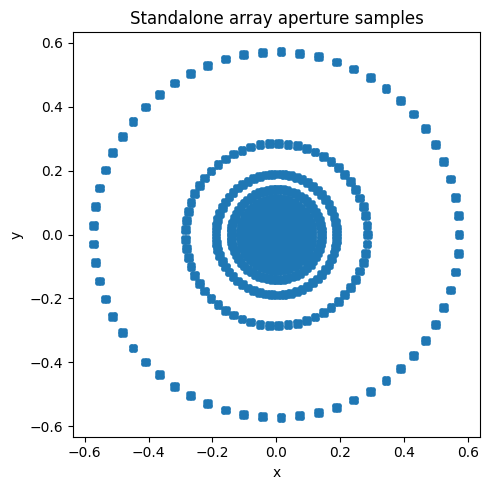

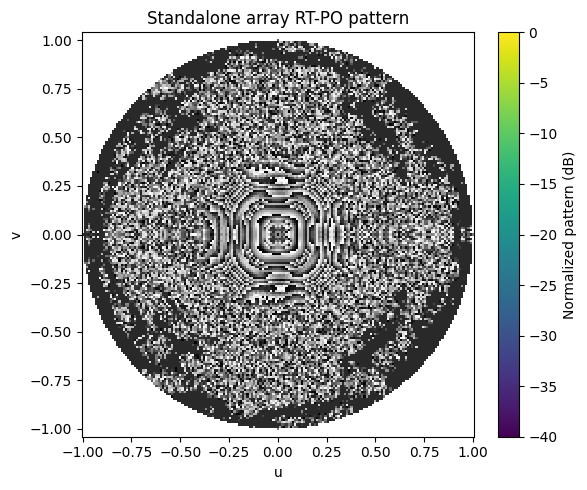

In [14]:
# Frequency / wavelength
f = 30e9
wavelength = c0 / f

# Build array
array = build_rect_array(nx=4, ny=4, dx=0.5, dy=0.5, wavelength=wavelength, z0=0.0)

# No-lens equivalent: use an aperture plane directly above the array
lens = LensSystem(
    surfaces=[],
    medium_eps=[1.0]
)

# Broadside
for e in array.elements:
    e.phase_exc = 0.0

# For no-lens case, use a custom simple direct propagation to aperture
def direct_to_aperture_no_lens(array, aperture_z, wavelength, n_theta=31, n_phi=61):
    launched = launch_rays_from_array(array, n_theta=n_theta, n_phi=n_phi)
    pts, dirs, phases, amps = [], [], [], []

    k0 = 2 * np.pi / wavelength
    for item in launched:
        ray = item["ray"]
        dz = ray.k_hat[2]
        if dz <= 1e-12:
            continue
        t = (aperture_z - ray.r0[2]) / dz
        if t <= 0:
            continue
        p = ray.r0 + t * ray.k_hat
        phase = ray.phase + k0 * t
        pts.append(p)
        dirs.append(ray.k_hat)
        phases.append(phase)
        amps.append(ray.amp)

    return {
        "points": np.array(pts),
        "dirs": np.array(dirs),
        "phases": np.array(phases),
        "amps": np.array(amps)
    }

ap_data = direct_to_aperture_no_lens(array, aperture_z=3*wavelength, wavelength=wavelength)
plot_aperture_points(ap_data["points"], title="Standalone array aperture samples")

tri = build_ray_tubes(ap_data)
rt_fields = compute_ray_tube_fields(ap_data, tri)
currents = aperture_fields_and_currents(rt_fields)
U, V, E_ff, mask = far_field_po(currents, wavelength=wavelength)
db = normalize_db(E_ff)

plot_uv_pattern(U, V, db, mask, title="Standalone array RT-PO pattern")

In [15]:
f = 30e9
wavelength = c0 / f

array = build_rect_array(nx=4, ny=4, dx=0.5, dy=0.5, wavelength=wavelength, z0=0.0)

# Simple two-interface lens: air -> dielectric -> air
surf1 = ConicSurface(
    name="lens_bottom",
    eps_r_above=2.0,
    eps_r_below=1.0,
    c=-2.0,
    K=-1.1,
    z0=0.044
)

surf2 = ConicSurface(
    name="lens_top",
    eps_r_above=1.0,
    eps_r_below=2.0,
    c=-1,
    K=0.2,
    z0=0.086
)

lens = LensSystem(
    surfaces=[surf1, surf2],
    medium_eps=[1.0, 2.0, 1.0]
)

# Use reverse ray tracing to compute phases for a desired scan direction
scan_dir = np.array([0.0, 0.0, 1.0])
phases = reverse_ray_tracing(
    array=array,
    lens=lens,
    wavelength=wavelength,
    scan_dir=scan_dir,
    ref_plane_z=0.12
)

print("Element phases (rad):")
print(phases.reshape(4, 4))

# Direct ray tracing to aperture
ap_data = direct_ray_tracing_to_aperture(
    array=array,
    lens=lens,
    aperture_z=0.12,
    wavelength=wavelength,
    n_theta=25,
    n_phi=49
)

print("Aperture samples:", len(ap_data["points"]))
plot_aperture_points(ap_data["points"], title="Lens aperture samples")

tri = build_ray_tubes(ap_data)
rt_fields = compute_ray_tube_fields(ap_data, tri)
currents = aperture_fields_and_currents(rt_fields)
U, V, E_ff, mask = far_field_po(currents, wavelength=wavelength)
db = normalize_db(E_ff)

plot_uv_pattern(U, V, db, mask, title="Array + lens RT-PO pattern")

Element phases (rad):
[[-0.08465488  0.          0.         -0.08465488]
 [ 0.          0.08460735  0.08460735  0.        ]
 [ 0.          0.08460735  0.08460735  0.        ]
 [-0.08465488  0.          0.         -0.08465488]]
Aperture samples: 0


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

<Figure size 500x500 with 0 Axes>

In [ ]:
f = 30e9
wavelength = c0 / f

array = build_rect_array(nx=4, ny=4, dx=0.5, dy=0.5, wavelength=wavelength, z0=0.0)

surf1 = PlaneSurface(
    name="slab_bottom",
    eps_r_above=2.0,
    eps_r_below=1.0,
    z_plane=0.02
)

surf2 = PlaneSurface(
    name="slab_top",
    eps_r_above=1.0,
    eps_r_below=2.0,
    z_plane=0.03
)

lens = LensSystem(
    surfaces=[surf1, surf2],
    medium_eps=[1.0, 2.0, 1.0]
)

for e in array.elements:
    e.phase_exc = 0.0

ap_data = direct_ray_tracing_to_aperture(
    array=array,
    lens=lens,
    aperture_z=0.05,
    wavelength=wavelength,
    n_theta=21,
    n_phi=41
)

print("Aperture samples:", len(ap_data["points"]))

if len(ap_data["points"]) == 0:
    raise RuntimeError("No rays reached aperture")

plot_aperture_points(ap_data["points"], title="Lens aperture samples")

tri = build_ray_tubes(ap_data)
rt_fields = compute_ray_tube_fields(ap_data, tri)
currents = aperture_fields_and_currents(rt_fields)
U, V, E_ff, mask = far_field_po(currents, wavelength=wavelength)
db = normalize_db(E_ff)

plot_uv_pattern(U, V, db, mask, title="Array + slab RT-PO pattern")